In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
from sklearn.model_selection import train_test_split

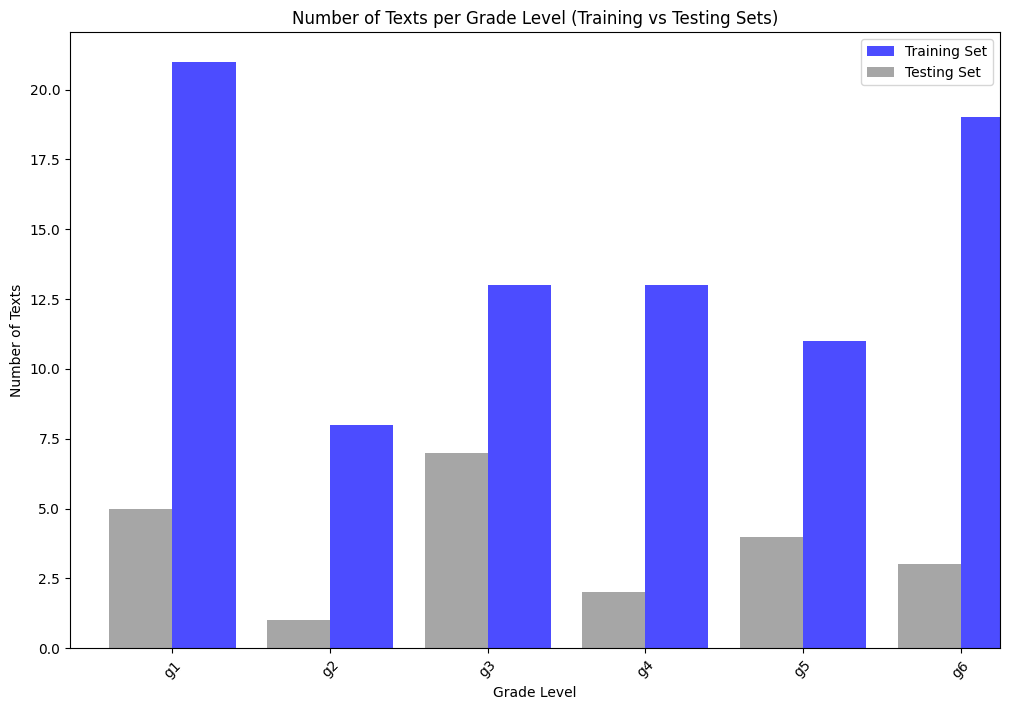

In [32]:
base_dir = "../txt/utf/"
random_seed = 42
test_size = 0.2

all_files = []
for root, _, files in os.walk(base_dir):
    for file in files:
        if file.endswith((".txt", ".pdf", ".docx")):
            all_files.append(os.path.join(root, file))

random.seed(random_seed)
random.shuffle(all_files)
train_files, test_files = train_test_split(all_files, test_size=test_size, random_state=random_seed)
    
def extract_grade_level(file_path):
    parts = file_path.split(os.sep)
    for part in parts:
        if part.startswith("g"):  # Assuming grade levels are prefixed with "g"
            return part
    return "Unknown"

train_grades = [extract_grade_level(file) for file in train_files]
test_grades = [extract_grade_level(file) for file in test_files]

train_grade_counts = pd.Series(train_grades).value_counts()
test_grade_counts = pd.Series(test_grades).value_counts()

plt.figure(figsize=(12, 8))

# Plot training set counts
train_grade_counts.sort_index().plot(
    kind='bar', color='blue', alpha=0.7, label='Training Set', position=0, width=0.4
)

test_grade_counts.sort_index().plot(
    kind='bar', color='grey', alpha=0.7, label='Testing Set', position=1, width=0.4
)

plt.title('Number of Texts per Grade Level (Training vs Testing Sets)')
plt.xlabel('Grade Level')
plt.ylabel('Number of Texts')
plt.xticks(rotation=45)
plt.legend()
plt.show()
    

In [3]:
df = pd.read_csv('../tables/dataset.csv')
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   text_num  grade_level  stride_len  stride_index  n_gram  noun_tr  verb_tr  \
0        44            4           1             0   isang      0.0      0.0   
1        44            4           1             1    araw      1.0      0.0   
2        44            4           1             2     may      0.0      1.0   
3        44            4           1             3   isang      0.0      0.0   
4        44            4           1             4  maliit      0.0      0.0   

   type_tr  lex_density  lex_foreign  sent_len  word_len  word_num  syll_num  \
0      1.0          0.0          0.0       NaN       5.0       NaN       1.0   
1      1.0          1.0          0.0       NaN       4.0       NaN       1.0   
2      1.0          1.0          0.0       NaN       3.0       NaN       1.0   
3      1.0          0.0          0.0       NaN       5.0       NaN       1.0   
4      1.0          1.0          0.0       NaN       6.0       NaN       2.0   

   poly_n

In [3]:
# Feature data type
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195438 entries, 0 to 195437
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   text_num      195438 non-null  int64  
 1   grade_level   195438 non-null  int64  
 2   stride_len    195438 non-null  int64  
 3   stride_index  195438 non-null  int64  
 4   n_gram        195438 non-null  object 
 5   noun_tr       195438 non-null  float64
 6   verb_tr       195438 non-null  float64
 7   type_tr       195438 non-null  float64
 8   lex_density   195438 non-null  float64
 9   lex_foreign   195438 non-null  float64
 10  sent_len      0 non-null       float64
 11  word_len      195438 non-null  float64
 12  word_num      0 non-null       float64
 13  syll_num      195438 non-null  float64
 14  poly_num      195438 non-null  int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 22.4+ MB
None


In [4]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text_num             0
grade_level          0
stride_len           0
stride_index         0
n_gram               0
noun_tr              0
verb_tr              0
type_tr              0
lex_density          0
lex_foreign          0
sent_len        195438
word_len             0
word_num        195438
syll_num             0
poly_num             0
dtype: int64


In [7]:
# Summary statistics of numerical columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       text_num  grade_level  stride_len  stride_index    noun_tr    verb_tr  \
count      40.0         40.0    40.00000     40.000000  40.000000  40.000000   
mean      555.0          0.0     3.42500      5.625000   0.331168   0.076247   
std         0.0          0.0     1.72296      3.887439   0.191258   0.145287   
min       555.0          0.0     2.00000      0.000000   0.000000   0.000000   
25%       555.0          0.0     2.00000      2.000000   0.200000   0.000000   
50%       555.0          0.0     3.00000      5.500000   0.333300   0.000000   
75%       555.0          0.0     5.00000      9.000000   0.500000   0.050000   
max       555.0          0.0    11.00000     13.000000   0.666700   0.500000   

       type_tr  lex_density  lex_foreign  sent_len   word_len  word_num  \
count     40.0    40.000000    40.000000       0.0  40.000000       0.0   
mean       1.0     0.407420     0.221815       NaN   4.269825       NaN   
std        0.0     0.208734     0

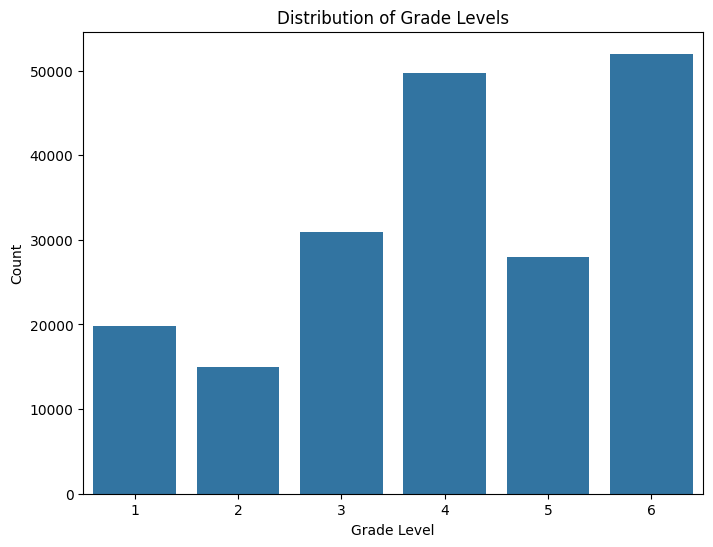

In [ ]:
# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

5102


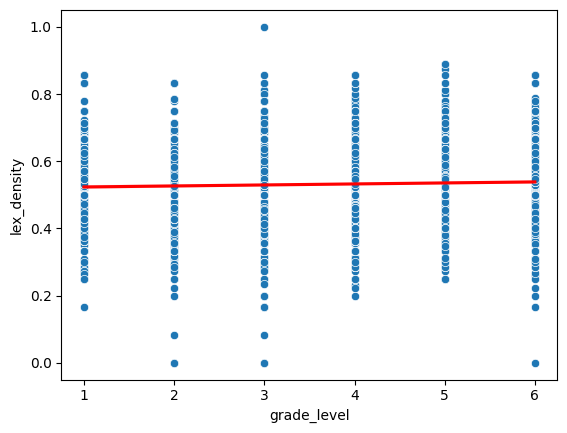

In [ ]:
filtered_df = df[df['stride_len'] > 3]
print(len(filtered_df))
sns.scatterplot(x='grade_level', y='lex_density', data=filtered_df)
sns.regplot(x='grade_level', y='lex_density', data=filtered_df, scatter=False, color='red')
plt.show()

In [ ]:
sns.scatterplot(x='grade_level', y='noun_tr', data=df)
sns.regplot(x='grade_level', y='noun_tr', data=df, scatter=False, color='red')
plt.title('Relationship Between Grade Level and Lexical Density')
plt.show()